# Coletando os dados utilizando API do Coingecko

In [37]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import datetime as dt

url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
params = {"vs_currency": "usd", "days": "365"}

data = requests.get(url, params=params).json()

prices = data['prices']

df = pd.DataFrame(prices, columns=['timestamp', 'price'])

df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')

df.set_index('timestamp', inplace=True)

df.head()

,price
timestamp,
2024-12-05,98881.469456
2024-12-06,97201.500364
2024-12-07,99973.851507
2024-12-08,99781.829992
2024-12-09,101235.371703


# Limpeza e ajuste dos dados

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 366 entries, 2024-12-05 00:00:00 to 2025-12-04 19:51:01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   366 non-null    float64
dtypes: float64(1)
memory usage: 5.7 KB


In [39]:
df.describe()

,price
count,366.000000
mean,102351.004157
std,11229.112127
min,76329.090356
25%,94482.183180
50%,103713.915381
75%,110961.632438
max,124773.508231


In [40]:
df.isna().sum()

,0
price,0


# Análise exploratória dos dados
Buscando por padrões, tendências e volatilidade


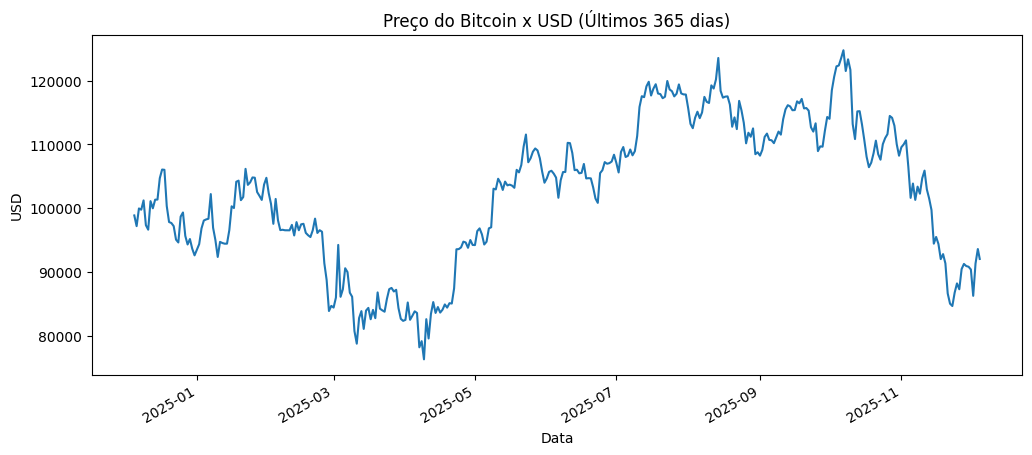

In [41]:
df['price'].plot(figsize=(12, 5))

plt.title("Preço do Bitcoin x USD (Últimos 365 dias)")

plt.xlabel("Data")

plt.ylabel("USD")
plt.show()

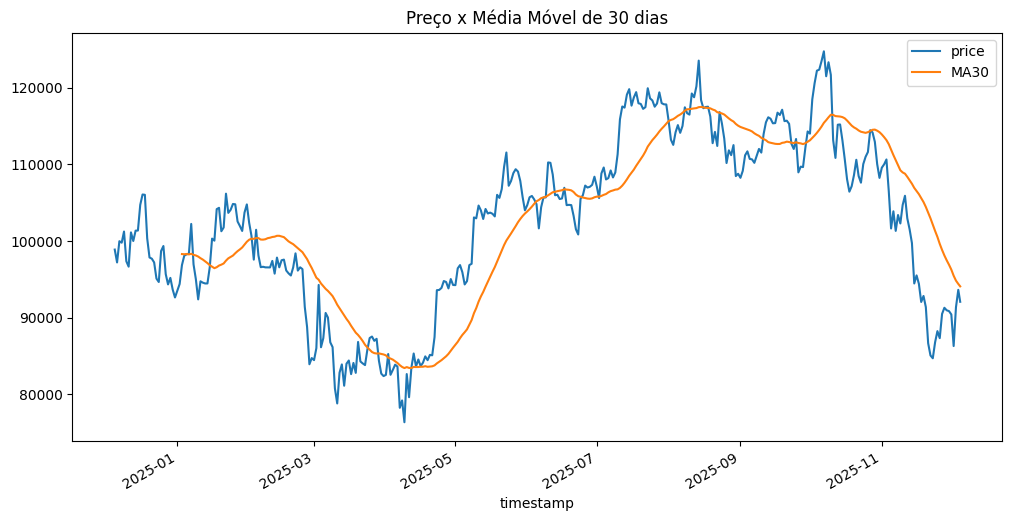

In [42]:
df['MA30'] = df['price'].rolling(window=30).mean()

df[['price', 'MA30']].plot(figsize=(12, 6))

plt.title("Preço x Média Móvel de 30 dias")
plt.show()

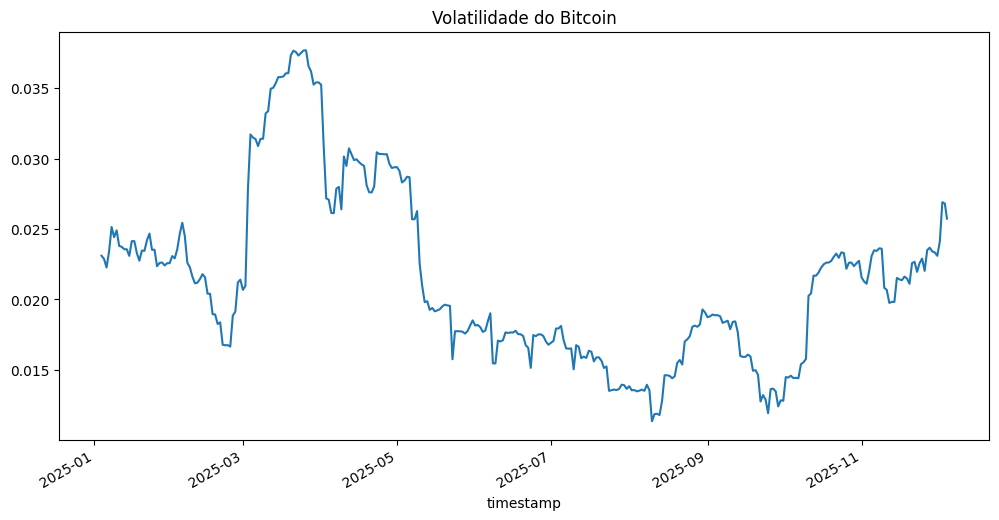

In [43]:
df['volatility'] = df['price'].pct_change().rolling(window=30).std()

df['volatility'].plot(figsize=(12, 6))

plt.title("Volatilidade do Bitcoin")
plt.show()

Gráfico representando a máxima queda por período  (drawdown)

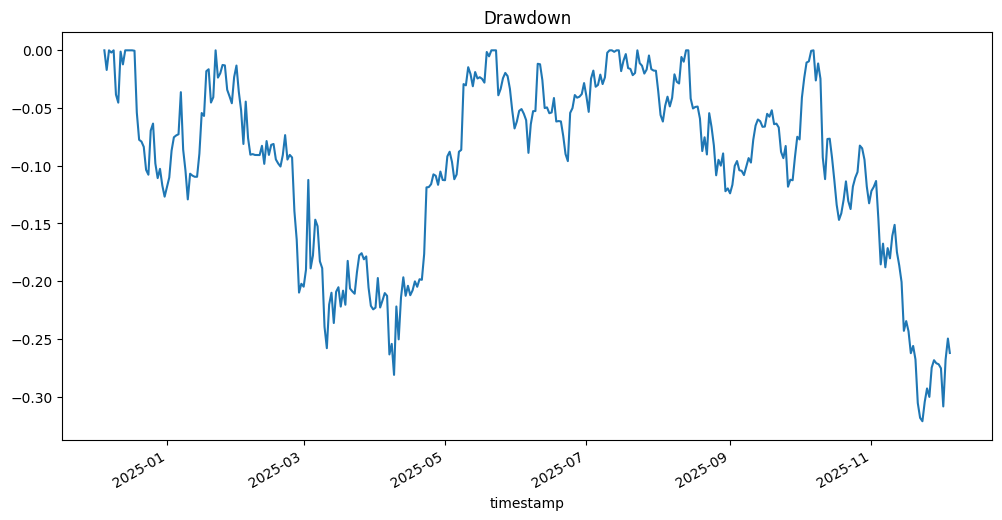

In [44]:
df['cummax'] = df['price'].cummax()
df['drawdown'] = (df['price'] - df['cummax']) / df['cummax']

df['drawdown'].plot(figsize=(12, 6))

plt.title("Drawdown")
plt.show()

## Pequeno modelo de previsão utilizando a biblioteca Prophet

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


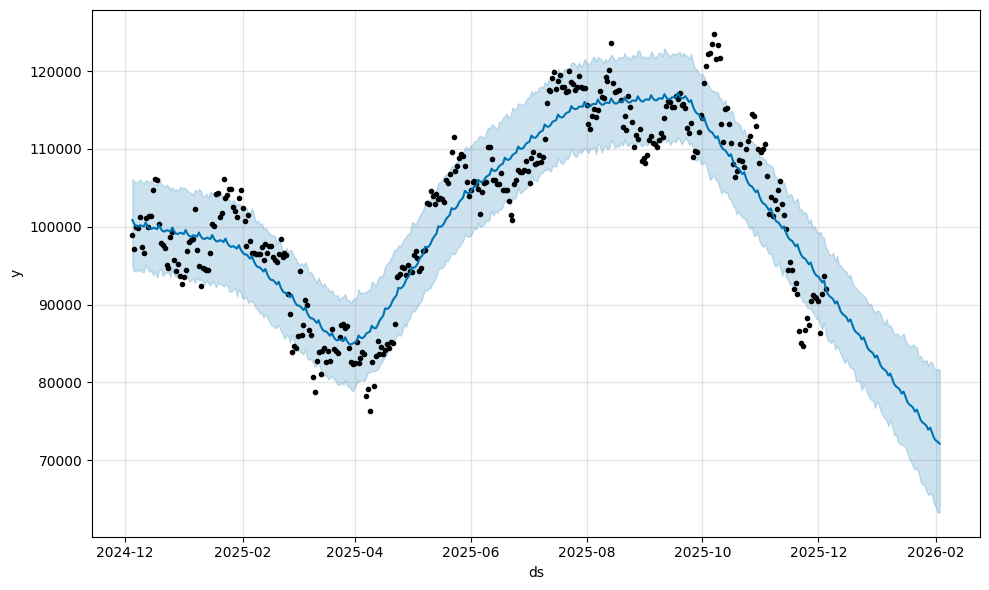

In [48]:
df_prophet = df.reset_index()[['timestamp', 'price']]
df_prophet.columns = ['ds', 'y']

model = Prophet()
model.fit(df_prophet)

future = model.make_future_dataframe(periods=60)
forecast = model.predict(future)

model.plot(forecast)
plt.show()